In [30]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [2]:
with open("data/train.pkl", "rb") as file:
    X_train = pickle.load(file).reset_index()

Pasuje pozamieniać znaki, które dolegają do słów na puste stingi

In [7]:
X_train["Message"] = X_train["Message"].str.replace(",", " ")
X_train["Message"] = X_train["Message"].str.replace("\n", " ")

In [8]:
#help(x.str.replace)

In [9]:
X_train.head()

,index,Status,Message
0,973,2,From OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM...
1,4592,0,Return-Path: skip@pobox.com .Delivery-Date: Sa...
2,13730,0,From ilug-admin@linux.ie Fri Jul 19 23:44:22 ...
3,3046,2,From travelincentives@aol.com Mon Aug 6 20:0...
4,6790,0,From rpm-list-admin@freshrpms.net Wed Jul 31 ...


In [10]:
np.mean(X_train["Message"].str.split(" ").str[1].str.contains("@"))

np.float64(0.9739320165365182)

In [11]:
email = X_train["Message"].str.split(" ")

In [12]:
email_2 = email.apply(lambda x: x[np.argmax(np.char.lower(np.array(x)) == "from") + 1])

In [13]:
email_2.head(30)

0     OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM@SMTP...
1                                        skip@pobox.com
2                                   ilug-admin@linux.ie
3                              travelincentives@aol.com
4                          rpm-list-admin@freshrpms.net
5                                   rssfeeds@jmason.org
6                                seseko7@worldemail.com
7                          rpm-list-admin@freshrpms.net
8                                        pfxljt@aol.com
9                                   rssfeeds@jmason.org
10                         rpm-list-admin@freshrpms.net
11                             joeoli6653@earthlink.net
12                             hothose2r@eudoramail.com
13        spamassassin-talk-admin@lists.sourceforge.net
14                                          timhunt.net
15                          exmh-users-admin@redhat.com
16                                  fork-admin@xent.com
17                                        hq.pro

In [14]:
email_2.tail(30)

17386                        rssfeeds@jmason.org
17387                      localhost.localdomain
17388                        rssfeeds@jmason.org
17389                              hq.pro-ns.net
17390               rpm-list-admin@freshrpms.net
17391                        ilug-admin@linux.ie
17392                        ilug-admin@linux.ie
17393                   updates-admin@ximian.com
17394                        fork-admin@xent.com
17395               rpm-list-admin@freshrpms.net
17396                            martenb@aol.com
17397                        ilug-admin@linux.ie
17398                        fork-admin@xent.com
17399                        rssfeeds@jmason.org
17400    razor-users-admin@lists.sourceforge.net
17401                        rssfeeds@jmason.org
17402              exmh-workers-admin@redhat.com
17403          hB6rT8aL9tXArsQ@tcts1.seed.net.tw
17404                        fork-admin@xent.com
17405                        ilug-admin@linux.ie
17406               

In [15]:
temp = email_2.str.split("@")

In [16]:
email_2 = pd.DataFrame(email_2)

In [17]:
email_2

,Message
0,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM@SMTP...
1,skip@pobox.com
2,ilug-admin@linux.ie
3,travelincentives@aol.com
4,rpm-list-admin@freshrpms.net
...,...
17411,ilug-admin@linux.ie
17412,guido@python.org
17413,fork-admin@xent.com
17414,exmh-users-admin@redhat.com


In [18]:
email_2["part_1"] = temp.str[0]

In [19]:
email_2["domain"] = temp.str[1]

In [20]:
email_2 = pd.concat([X_train["Status"], email_2], axis=1)

In [21]:
email_2.head(30)

,Status,Message,part_1,domain
0,2,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM@SMTP...,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM,SMTP1.ADMANMAIL.COM
1,0,skip@pobox.com,skip,pobox.com
2,0,ilug-admin@linux.ie,ilug-admin,linux.ie
3,2,travelincentives@aol.com,travelincentives,aol.com
4,0,rpm-list-admin@freshrpms.net,rpm-list-admin,freshrpms.net
5,0,rssfeeds@jmason.org,rssfeeds,jmason.org
6,2,seseko7@worldemail.com,seseko7,worldemail.com
7,0,rpm-list-admin@freshrpms.net,rpm-list-admin,freshrpms.net
8,2,pfxljt@aol.com,pfxljt,aol.com
9,0,rssfeeds@jmason.org,rssfeeds,jmason.org


In [22]:
important_domains = email_2["domain"].value_counts()
important_domains = important_domains[important_domains > 100]#0.01*X_train.shape[0]]

In [23]:
important_domains.shape

(11,)

In [24]:
pd.DataFrame(important_domains).reset_index()

,domain,count
0,xent.com,3673
1,jmason.org,2282
2,linux.ie,1834
3,lists.sourceforge.net,1562
4,freshrpms.net,1305
5,redhat.com,794
6,hotmail.com,309
7,yahoo.com,257
8,perl.org,253
9,returns.groups.yahoo.com,223


In [25]:
email_2 = email_2.merge(pd.DataFrame(important_domains).reset_index(),how="left", left_on="domain", right_on="domain")

In [26]:
email_2["Important_domain"] = np.where(~email_2["count"].isna(), email_2["domain"], "No_important")

In [27]:
email_2.head()

,Status,Message,part_1,domain,count,Important_domain
0,2,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM@SMTP...,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM,SMTP1.ADMANMAIL.COM,NaN,No_important
1,0,skip@pobox.com,skip,pobox.com,NaN,No_important
2,0,ilug-admin@linux.ie,ilug-admin,linux.ie,1834.0,linux.ie
3,2,travelincentives@aol.com,travelincentives,aol.com,120.0,aol.com
4,0,rpm-list-admin@freshrpms.net,rpm-list-admin,freshrpms.net,1305.0,freshrpms.net


In [28]:
email_2.isna().mean()

Status              0.000000
Message             0.000000
part_1              0.000000
domain              0.072347
count               0.275838
Important_domain    0.000000
dtype: float64

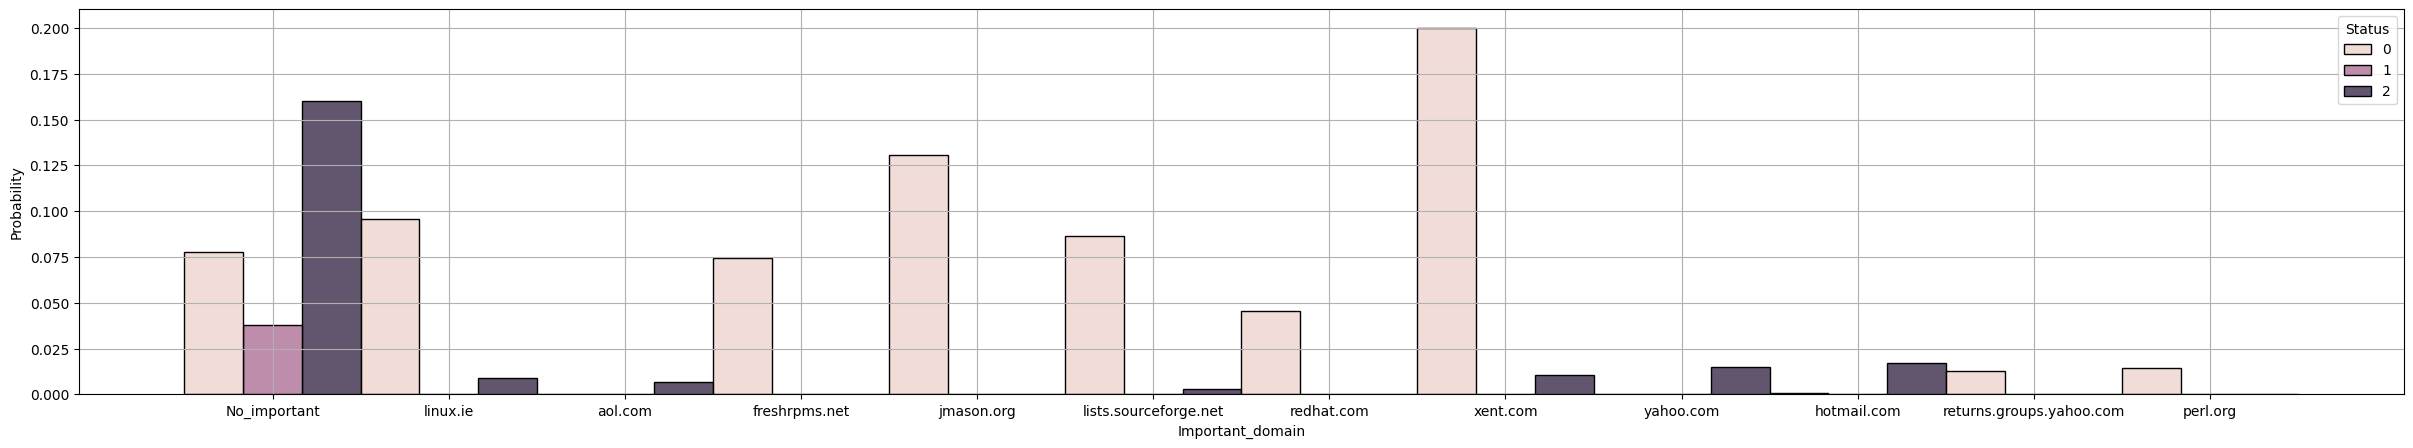

In [31]:
plt.figure(figsize=(30, 5))
sns.histplot(data=email_2, x="Important_domain", hue="Status", multiple="dodge", stat="probability")
plt.grid("on")
plt.show()

In [32]:
counted = email_2.groupby(["Important_domain","Status"]).size().reset_index(name="count")

In [33]:
counted.head()

,Important_domain,Status,count
0,No_important,0,1358
1,No_important,1,656
2,No_important,2,2790
3,aol.com,2,120
4,freshrpms.net,0,1299


In [34]:
domains = counted.groupby("Important_domain")["count"].sum().reset_index(name="sum").merge(counted, how="right", on="Important_domain")

In [35]:
domains["count"] = domains["count"] / domains["sum"]

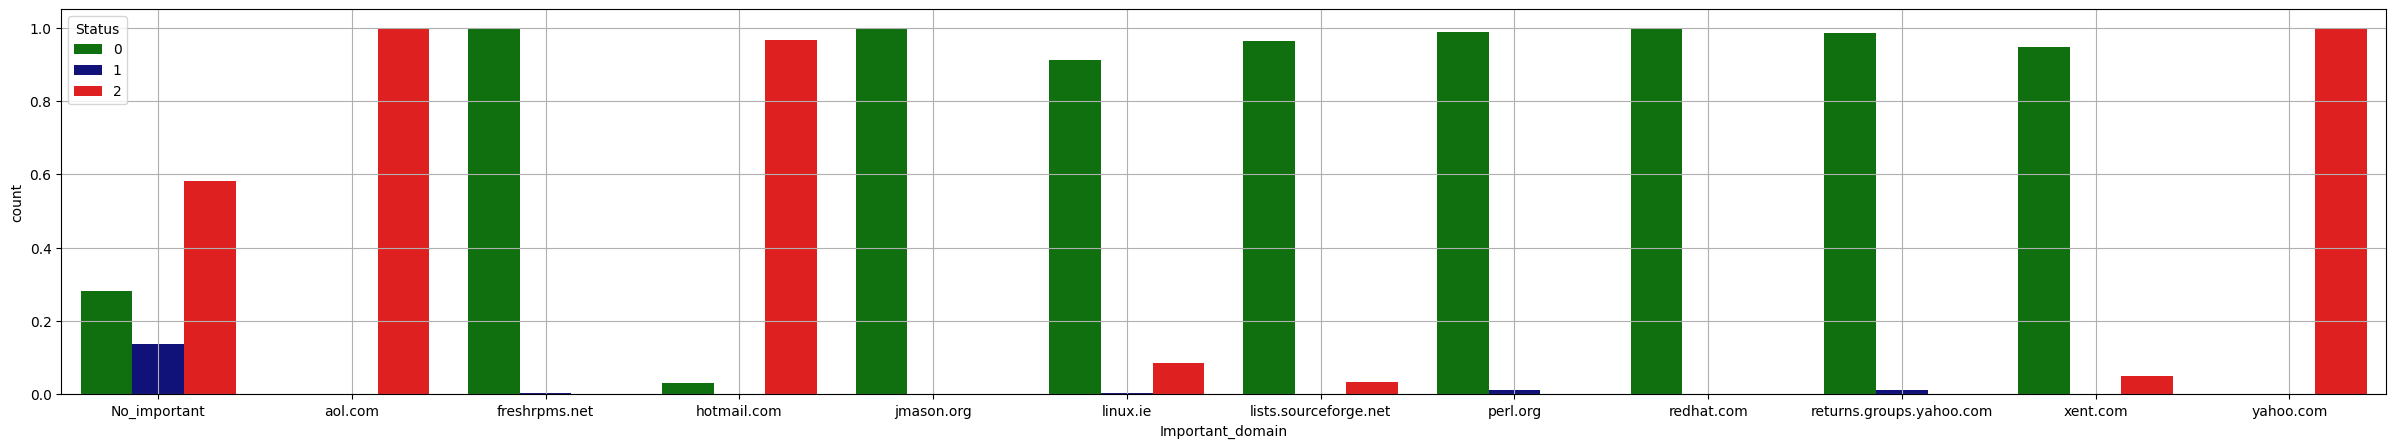

In [36]:
plt.figure(figsize=(30, 5))
sns.barplot(data=domains, x="Important_domain", hue="Status", y="count", palette=["green", "darkblue", "red"])
plt.grid("on")
plt.show()

Widzimy, że istotnie domena może mieć ogromne znaczenie, sprawdźmy dla większego zakresu domen

In [37]:
email_2.head()

,Status,Message,part_1,domain,count,Important_domain
0,2,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM@SMTP...,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM,SMTP1.ADMANMAIL.COM,NaN,No_important
1,0,skip@pobox.com,skip,pobox.com,NaN,No_important
2,0,ilug-admin@linux.ie,ilug-admin,linux.ie,1834.0,linux.ie
3,2,travelincentives@aol.com,travelincentives,aol.com,120.0,aol.com
4,0,rpm-list-admin@freshrpms.net,rpm-list-admin,freshrpms.net,1305.0,freshrpms.net


In [38]:
email_2["domain"].isna().mean()

np.float64(0.07234726688102894)

In [39]:
email_2["domain"] = np.where(email_2["domain"].isna(), "unknown", email_2["domain"])

In [40]:
threshold = 50
important_domains = email_2["domain"].value_counts()
important_domains = important_domains[important_domains > threshold]#0.01*X_train.shape[0]]

In [41]:
important_domains, important_domains.shape

(domain
 xent.com                    3673
 jmason.org                  2282
 linux.ie                    1834
 lists.sourceforge.net       1562
 freshrpms.net               1305
 unknown                     1260
 redhat.com                   794
 hotmail.com                  309
 yahoo.com                    257
 perl.org                     253
 returns.groups.yahoo.com     223
 aol.com                      120
 msn.com                      100
 insurancemail.net            100
 taint.org                     96
 insiq.us                      76
 python.org                    76
 petting-zoo.net               70
 securityfocus.com             66
 comcast.net                   65
 pobox.com                     60
 btamail.net.cn                60
 eudoramail.com                55
 Name: count, dtype: int64,
 (23,))

In [45]:
email_2 = email_2.merge(pd.DataFrame(important_domains).reset_index(),how="left", left_on="domain", right_on="domain")

In [ ]:
email_2.drop(["count_x", "count_y"], axis=1, inplace=True)

In [47]:
email_2.head()

,Status,Message,part_1,domain,Important_domain,count
0,2,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM@SMTP...,OWNER-NOLIST-SGODAILY*JM**NETNOTEINC*-COM,SMTP1.ADMANMAIL.COM,No_important,NaN
1,0,skip@pobox.com,skip,pobox.com,No_important,60.0
2,0,ilug-admin@linux.ie,ilug-admin,linux.ie,linux.ie,1834.0
3,2,travelincentives@aol.com,travelincentives,aol.com,aol.com,120.0
4,0,rpm-list-admin@freshrpms.net,rpm-list-admin,freshrpms.net,freshrpms.net,1305.0


In [48]:
email_2["Important_domain"] = np.where(~email_2["count"].isna(), email_2["domain"], "No_important")

In [49]:
email_2.isna().mean()

Status              0.000000
Message             0.000000
part_1              0.000000
domain              0.000000
Important_domain    0.000000
count               0.156178
dtype: float64

In [50]:
important_domains.reset_index()["domain"][0]

'xent.com'

In [51]:
counted = email_2.groupby(["Important_domain","Status"]).size().reset_index(name="count")
domains = counted.groupby("Important_domain")["count"].sum().reset_index(name="sum").merge(counted, how="right", on="Important_domain")
domains["count"] = domains["count"] / domains["sum"]

In [52]:
domains.head()

,Important_domain,sum,Status,count
0,No_important,2720,0,0.251103
1,No_important,2720,1,0.056985
2,No_important,2720,2,0.691912
3,aol.com,120,2,1.000000
4,btamail.net.cn,60,2,1.000000


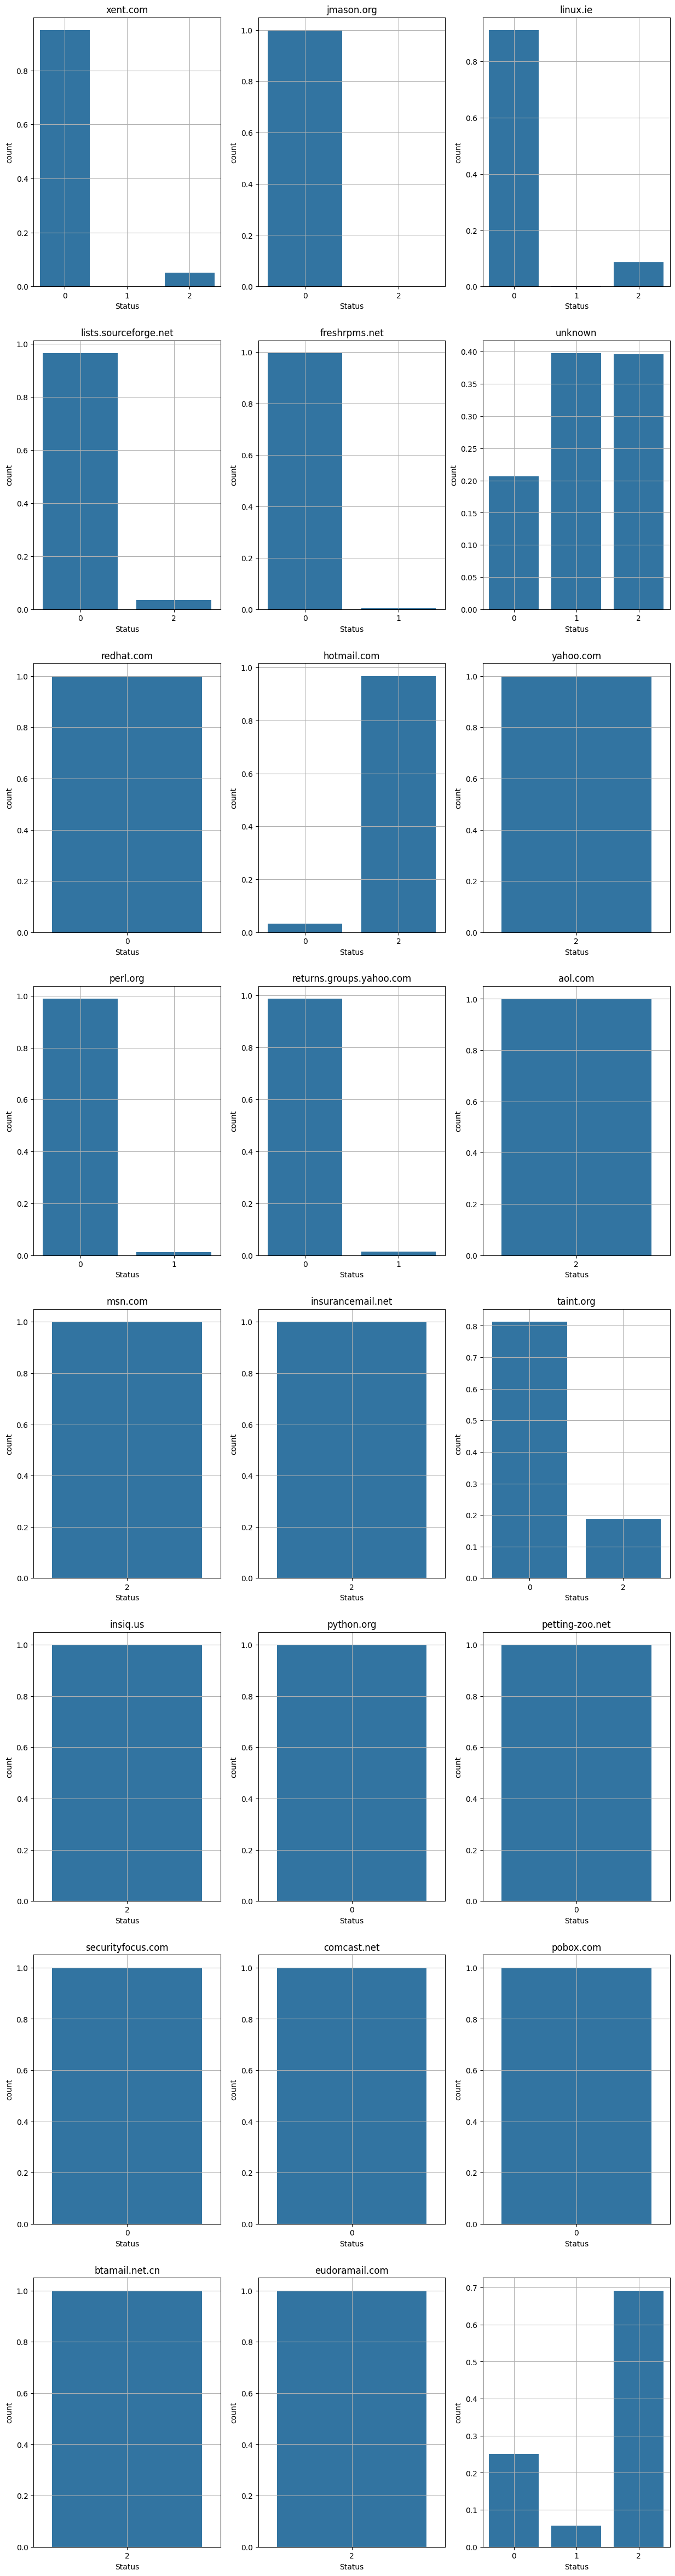

In [53]:
d = important_domains.reset_index()["domain"]
plt.figure(figsize=(15, 60))
for index in range(len(important_domains)):
    plt.subplot(8, 3, index+1)
    sns.barplot(data=domains[domains["Important_domain"] == d[index]], x="Status", y="count")
    plt.grid("on")
    plt.title(d[index])

plt.subplot(8, 3, 24)
sns.barplot(data=domains[domains["Important_domain"] == "No_important"], x="Status", y="count")
plt.grid("on")
plt.show()

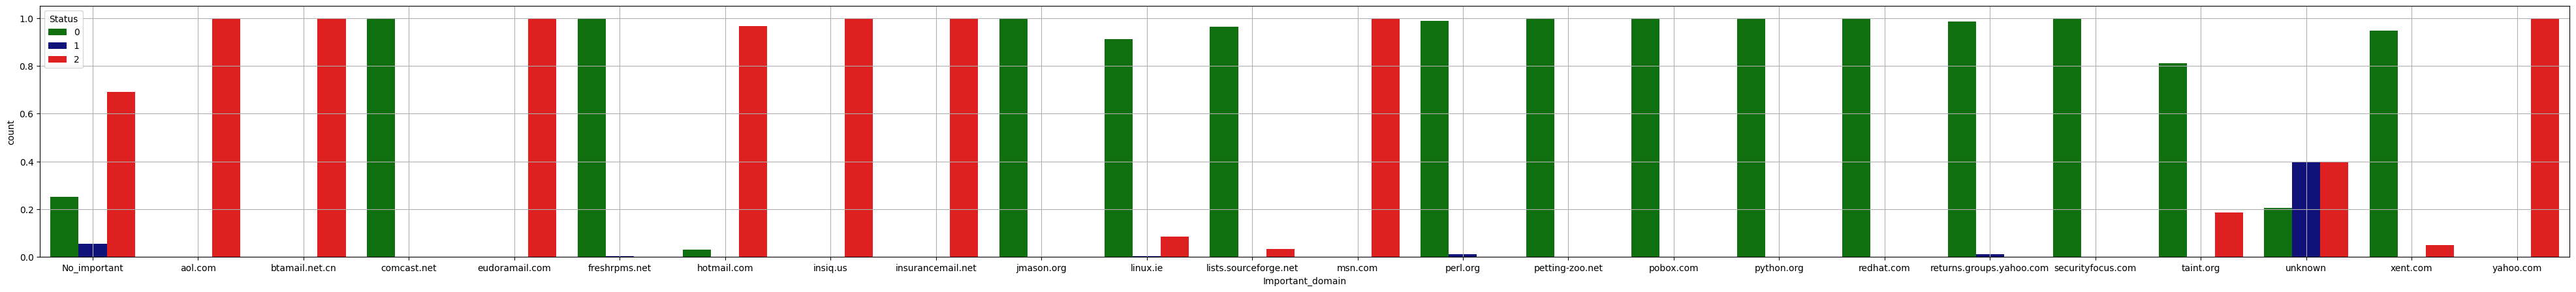

In [54]:
plt.figure(figsize=(50, 5))
sns.barplot(data=domains, x="Important_domain", hue="Status", y="count", palette=["green", "darkblue", "red"])
plt.grid("on")
plt.show()

## Wniosek 1: To czy dany email jest spamem, mocno zależy od domeny nadawcy - są takie domeny, gdzie 100% wysłanych maili to spam i odwrotnie

In [57]:
domains["Important_domain"].unique()

array(['No_important', 'aol.com', 'btamail.net.cn', 'comcast.net',
       'eudoramail.com', 'freshrpms.net', 'hotmail.com', 'insiq.us',
       'insurancemail.net', 'jmason.org', 'linux.ie',
       'lists.sourceforge.net', 'msn.com', 'perl.org', 'petting-zoo.net',
       'pobox.com', 'python.org', 'redhat.com',
       'returns.groups.yahoo.com', 'securityfocus.com', 'taint.org',
       'unknown', 'xent.com', 'yahoo.com'], dtype=object)

In [59]:
important_domains.index

Index(['xent.com', 'jmason.org', 'linux.ie', 'lists.sourceforge.net',
       'freshrpms.net', 'unknown', 'redhat.com', 'hotmail.com', 'yahoo.com',
       'perl.org', 'returns.groups.yahoo.com', 'aol.com', 'msn.com',
       'insurancemail.net', 'taint.org', 'insiq.us', 'python.org',
       'petting-zoo.net', 'securityfocus.com', 'comcast.net', 'pobox.com',
       'btamail.net.cn', 'eudoramail.com'],
      dtype='object', name='domain')